## This notebook was used to generate noise/outlier detection visualizations for the example report (lifestyle data)

In [2]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

# load data
df = pd.read_csv("../lifestyle_sustainability_data_processed.csv")

df.head()

df.columns


Index(['Age', 'LocalFoodFrequency', 'HomeSize', 'ClothingFrequency',
       'SustainableBrands', 'EnvironmentalAwareness', 'CommunityInvolvement',
       'MonthlyElectricityConsumption', 'MonthlyWaterConsumption',
       'UsingPlasticProducts', 'PhysicalActivities', 'Rating',
       'Location_Rural', 'Location_Suburban', 'Location_Urban',
       'DietType_Balanced', 'DietType_Mostly Animal-Based',
       'TransportationMode_Bike', 'TransportationMode_Car',
       'TransportationMode_Public Transit', 'EnergySource_Mixed',
       'EnergySource_Non-Renewable', 'HomeType_Apartment', 'HomeType_House',
       'Gender_Female', 'Gender_Male', 'Gender_Non-Binary',
       'DisposalMethods_Combination', 'DisposalMethods_Composting',
       'DisposalMethods_Landfill'],
      dtype='object')

### Attempt MAD with very low multiplier (because otherwise no noise is detected)

In [3]:
# use MAD only for continuous variables, preferably the most 
# impactful one towards the target variable
variable = "MonthlyElectricityConsumption"

# Calculate the median
median = df[variable].median()

# Calculate MAD
mad = np.median(np.abs(df[variable] - median))

# Define a threshold for noise detection
# adjust the numeric modifier for aggressiveness 
# e.g. try 2.5 or 4.5 etc.
# if the value is too high, you will find no noise (decrease in that case)
threshold = 2.0 * mad

# Detect noise
noise = df[np.abs(df[variable] - median) > threshold]

inliers = df.drop(noise.index)

print("Detected noise using MAD:")
noise

Detected noise using MAD:


,Age,LocalFoodFrequency,HomeSize,ClothingFrequency,SustainableBrands,EnvironmentalAwareness,CommunityInvolvement,MonthlyElectricityConsumption,MonthlyWaterConsumption,UsingPlasticProducts,...,EnergySource_Mixed,EnergySource_Non-Renewable,HomeType_Apartment,HomeType_House,Gender_Female,Gender_Male,Gender_Non-Binary,DisposalMethods_Combination,DisposalMethods_Composting,DisposalMethods_Landfill
6,25,3,600,0,1,5,2.0,80,1200,0,...,0,0,0,0,1,0,0,0,1,0
206,25,3,600,0,1,5,2.0,80,1200,0,...,0,0,0,0,1,0,0,0,1,0
223,61,1,1453,0,0,4,NaN,71,3414,2,...,0,0,1,0,0,0,0,1,0,0
229,66,0,1233,0,1,1,1.0,80,2824,3,...,1,0,0,0,0,0,1,0,1,0
267,64,2,590,2,1,5,1.0,78,4035,3,...,1,0,0,1,0,0,1,0,0,1
289,28,1,1351,0,1,4,0.0,58,3747,0,...,0,0,0,0,0,1,0,0,1,0
292,28,1,1978,0,1,5,0.0,69,3579,2,...,1,0,0,0,1,0,0,0,0,1
294,38,2,486,2,1,5,NaN,79,2228,2,...,1,0,1,0,0,1,0,0,1,0
301,40,1,1630,0,0,5,2.0,67,1079,0,...,0,1,0,1,1,0,0,0,0,0
303,33,3,2094,2,1,5,1.0,59,3680,0,...,0,1,0,1,0,0,1,0,1,0


In [4]:
print(len(inliers))
print(len(noise))

485
14


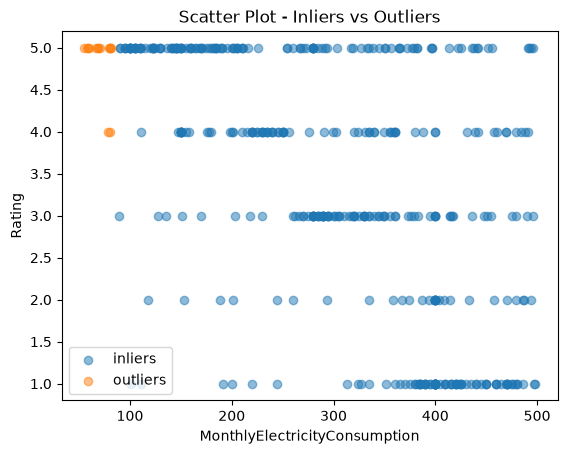

In [5]:
import matplotlib.pyplot as plt

variable = "MonthlyElectricityConsumption"
target = "Rating"

# if you want to reduce the number of points visualized
# sample a small amount of points, for example 300-500
inliers_sample = inliers.sample(400)
outliers_sample = noise.sample(14)

plt.scatter(inliers_sample[variable], inliers_sample[target], label="inliers", alpha=0.5)
plt.scatter(outliers_sample[variable], outliers_sample[target], label="outliers", alpha=0.5)

plt.xlabel(variable)
plt.ylabel(target)

plt.title("Scatter Plot - Inliers vs Outliers")
plt.legend()
plt.show()

### Isolation Forest can be used throughout the dataset

In [6]:
from sklearn.ensemble import IsolationForest
iso = IsolationForest(contamination=0.075) 

# fit isolation forest
y_pred = iso.fit_predict(df)

# separate outliers and inliers into separate DataFrames
outliers = df[y_pred != 1]
inliers = df[y_pred == 1]

print(f"Inliers: {len(inliers)}")
print(f"Outliers: {len(outliers)}")

Inliers: 461
Outliers: 38


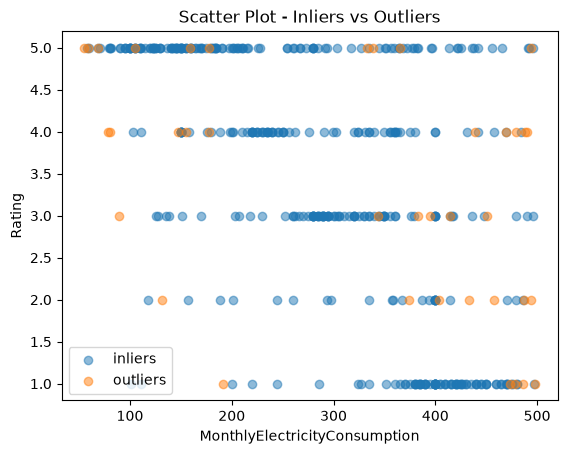

In [7]:
import matplotlib.pyplot as plt

# change the variable if you want to inspect this from other point of views
variable = "MonthlyElectricityConsumption"
target = "Rating"

# if you want to reduce the number of points visualized
# sample a small amount of points, for example 300-500
inliers_sample = inliers.sample(400)
outliers_sample = outliers.sample(38)

plt.scatter(inliers_sample[variable], inliers_sample[target], label="inliers", alpha=0.5)
plt.scatter(outliers_sample[variable], outliers_sample[target], label="outliers", alpha=0.5)

plt.xlabel(variable)
plt.ylabel(target)

plt.title("Scatter Plot - Inliers vs Outliers")
plt.legend()
plt.show()

<Axes: >

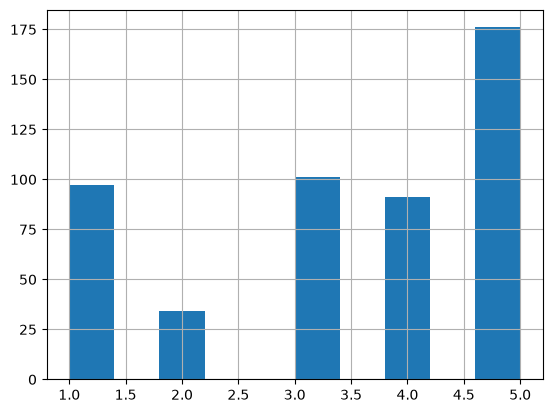

In [8]:
df['Rating'].hist()